# Concurvity, two ways

A model that sees both the calendar and a raw feature with its own seasonal cycle can't tell
"it's winter" from "this feature is doing its usual winter thing" — both look the same. It
copes by splitting credit between them in whatever way fits the training data, which only works
for as long as the feature's relationship to the calendar stays the same. The fix: give the
model the feature's *anomaly* against a seasonal normal instead of its raw value, so there's
nothing left for the calendar terms to fight over.

Two ways that relationship breaks, both real, both dated to plausible German events:
1. **Snowmelt timing** — hydro's seasonal peak drifts *earlier* year over year as winters warm.
   Gradual, no single event, builds up over a decade.
2. **Heat pump acceleration** — the 2022 gas-price shock triggers a jump in heat pump
   installations, so electric heating/cooling load's seasonal swing gets *wider*, in one step.

One negative result first: a rising *sensitivity* to a feature's anomaly, with the feature's own
relationship to the calendar unchanged, is **not** a concurvity problem — checked at the end.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNetCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

RNG_SEED = 0
plt.rcParams["figure.figsize"] = (9, 3.6)
plt.rcParams["axes.spines.top"] = plt.rcParams["axes.spines.right"] = False
PURPLE, GREEN = "#8172B2", "#55A868"
fourier_cols = ["sin1", "cos1", "sin2", "cos2"]
burn_in_years, train_years, test_years = 4, 5, 3
shift_year = burn_in_years + train_years  # boundary lands on 2022-01-01 given the start date below

## Shared machinery

One simulator covers all three cases. `phase_drift` moves X's seasonal timing continuously
(snowmelt); `amp_pre/amp_post` jump X's seasonal amplitude at the boundary (heat pumps);
`beta_pre/beta_post` jump the coefficient linking X's anomaly to price, with X's own calendar
relationship untouched (the negative-result check).

In [2]:
def simulate(phase0=0.30, phase_drift=0.0, amp_pre=3.0, amp_post=None,
             beta_pre=-3.0, beta_post=None, seed=RNG_SEED):
    amp_post = amp_pre if amp_post is None else amp_post
    beta_post = beta_pre if beta_post is None else beta_post
    rng = np.random.default_rng(seed)
    n_days = int((burn_in_years + train_years + test_years) * 365.25)
    dates = pd.date_range("2013-01-01", periods=n_days, freq="D")
    t = (dates - dates[0]).days / 365.25
    post = t >= shift_year

    demand_effect = 12 * np.sin(2 * np.pi * t) + 6 * np.cos(2 * np.pi * t)  # GBP/MWh baseline, never changes
    phase = phase0 + phase_drift * t
    amp = np.where(post, amp_post, amp_pre)
    beta = np.where(post, beta_post, beta_pre)
    seasonal_X = amp * np.sin(2 * np.pi * (t + phase))

    rho, sigma_innov = 0.97, 0.5
    anomaly_X = np.empty(n_days); anomaly_X[0] = 0.0
    innov = rng.normal(0, sigma_innov, n_days)
    for i in range(1, n_days):
        anomaly_X[i] = rho * anomaly_X[i - 1] + innov[i]

    X = 6.0 + seasonal_X + anomaly_X + rng.normal(0, 0.2, n_days)
    price = 70.0 + demand_effect + beta * anomaly_X + rng.normal(0, 4.0, n_days)

    df = pd.DataFrame({"t_years": t, "X": X, "price": price}, index=dates)
    df["doy"], df["year"] = df.index.dayofyear, df.index.year
    for i in [1, 2]:
        df[f"sin{i}"] = np.sin(2 * np.pi * i * df["t_years"])
        df[f"cos{i}"] = np.cos(2 * np.pi * i * df["t_years"])
    return df

def build_anomaly_feature(df):
    df = df.copy()
    df["climatology"] = np.nan
    for i, yr in enumerate(sorted(df["year"].unique())):
        if i == 0:
            continue
        hist = df[df["year"] < yr]
        clim = LinearRegression().fit(hist[fourier_cols], hist["X"])
        mask = df["year"] == yr
        df.loc[mask, "climatology"] = clim.predict(df.loc[mask, fourier_cols])
    df["climatology"] = df["climatology"].bfill()
    df["X_anomaly"] = df["X"] - df["climatology"]
    return df

def fit_enet(train_df, cols):
    m = make_pipeline(StandardScaler(), ElasticNetCV(l1_ratio=[.1, .5, .9, 1], cv=5, random_state=0, max_iter=10000))
    return m.fit(train_df[cols], train_df["price"])

def fit_xgb(train_df, cols):
    m = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=0)
    return m.fit(train_df[cols], train_df["price"])

def run_story(**sim_kwargs):
    df = build_anomaly_feature(simulate(**sim_kwargs))
    train = df[(df["t_years"] >= burn_in_years) & (df["t_years"] < shift_year)]
    test = df[df["t_years"] >= shift_year]
    features_raw, features_anom = fourier_cols + ["X"], fourier_cols + ["X_anomaly"]
    models = {
        "ElasticNet - raw": (fit_enet(train, features_raw), features_raw),
        "ElasticNet - anomaly": (fit_enet(train, features_anom), features_anom),
        "XGBoost - raw": (fit_xgb(train, features_raw), features_raw),
        "XGBoost - anomaly": (fit_xgb(train, features_anom), features_anom),
    }
    rmse = {name: mean_squared_error(test["price"], m.predict(test[cols])) ** 0.5 for name, (m, cols) in models.items()}
    return df, rmse

def plot_result(df, rmse, title, feature_label):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    axes[0].plot(df.index, df["X"], lw=0.5, color=PURPLE)
    axes[0].axvline(df[df["t_years"] >= shift_year].index.min(), color="k", ls="--", lw=1)
    axes[0].set_title(feature_label)
    names = list(rmse)
    axes[1].bar(names, [rmse[n] for n in names], color=[PURPLE, GREEN, PURPLE, GREEN])
    axes[1].set_title(f"test RMSE — {title}")
    plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right")
    fig.tight_layout()
    plt.show()

## Story 1 — snowmelt (hydro's timing drifts)

No single event: each year the spring melt arrives a little earlier than the last, so hydro's
seasonal peak slides steadily away from where the model learned to expect it — including within
the training window itself, which is what a real climate trend looks like.

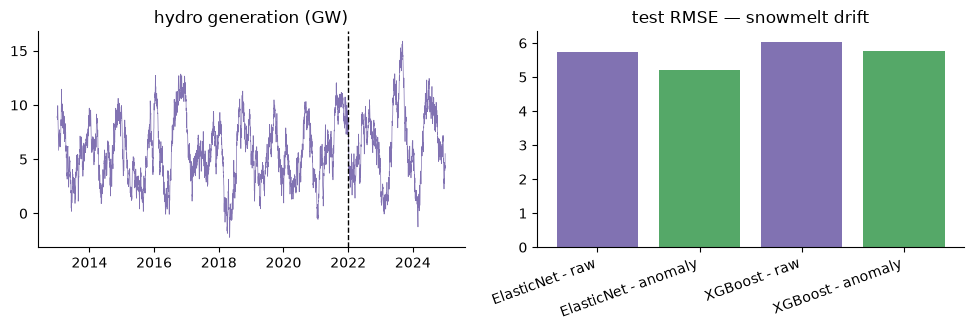

ElasticNet - raw        5.72
ElasticNet - anomaly    5.21
XGBoost - raw           6.04
XGBoost - anomaly       5.76
dtype: float64


In [3]:
df1, rmse1 = run_story(phase_drift=0.03)
plot_result(df1, rmse1, "snowmelt drift", "hydro generation (GW)")
print(pd.Series(rmse1).round(2))

## Story 2 — heat pump acceleration (load's amplitude jumps)

The 2022 gas-price shock (test period starts 2022-01-01 here) triggers a step up in heat pump
installations: electric heating/cooling load's seasonal swing widens from one year to the next,
with no gradual run-up.

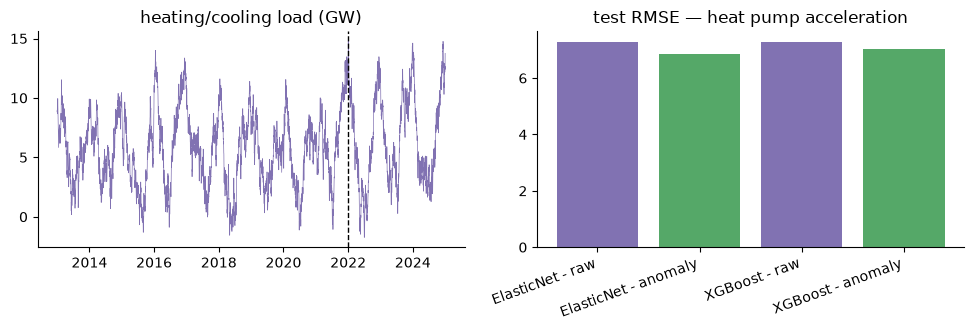

ElasticNet - raw        7.26
ElasticNet - anomaly    6.85
XGBoost - raw           7.29
XGBoost - anomaly       7.02
dtype: float64


In [4]:
df2, rmse2 = run_story(amp_pre=3.0, amp_post=6.0, beta_pre=3.0)  # more load -> higher price, not lower
plot_result(df2, rmse2, "heat pump acceleration", "heating/cooling load (GW)")
print(pd.Series(rmse2).round(2))

## The negative result — sensitivity alone doesn't count

Same size of change, same test window, but now only the *coefficient* linking X's anomaly to
price rises — X's own relationship to the calendar never moves.

In [5]:
df3, rmse3 = run_story(beta_pre=-3.0, beta_post=-6.0)
print(pd.Series(rmse3).round(2))

ElasticNet - raw        7.52
ElasticNet - anomaly    8.04
XGBoost - raw           8.88
XGBoost - anomaly       9.19
dtype: float64


The raw model does not get worse relative to the anomaly model here. That's not a coincidence:
algebraically, the calendar terms can absorb any fixed multiple of X's seasonal shape, whatever
that multiple is — the compensation trick that makes raw features fragile is indifferent to how
strongly X's effect is weighted. It only breaks when X's *own* seasonal timing or amplitude
moves, which is exactly what stories 1 and 2 do and this one deliberately doesn't.

## Conclusion

Same failure, two real causes, one fix, one thing the fix doesn't do. Concurvity bites when the
raw feature's *own* relationship to the calendar changes — whether that's a slow drift (snowmelt)
or a step (heat pumps) — and an anomaly feature, refreshed each year without retraining the
model, rides that out. It has nothing to offer against a feature whose effect on the target
simply gets stronger or weaker; that needs the coefficient itself re-estimated, not the feature
re-engineered.